# Lab 4: Contours
This lab focuses on detecting, analyzing, and manipulating contours in images using OpenCV. The exercises cover finding contours, drawing them, and computing properties like area and perimeter. Code is designed for a Jupyter Notebook, with images displayed inline using matplotlib.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Exercise 1: Finding and Drawing Contours
Task: Load a grayscale image, apply thresholding, find contours, and draw them on the original image.

(-0.5, 799.5, 449.5, -0.5)

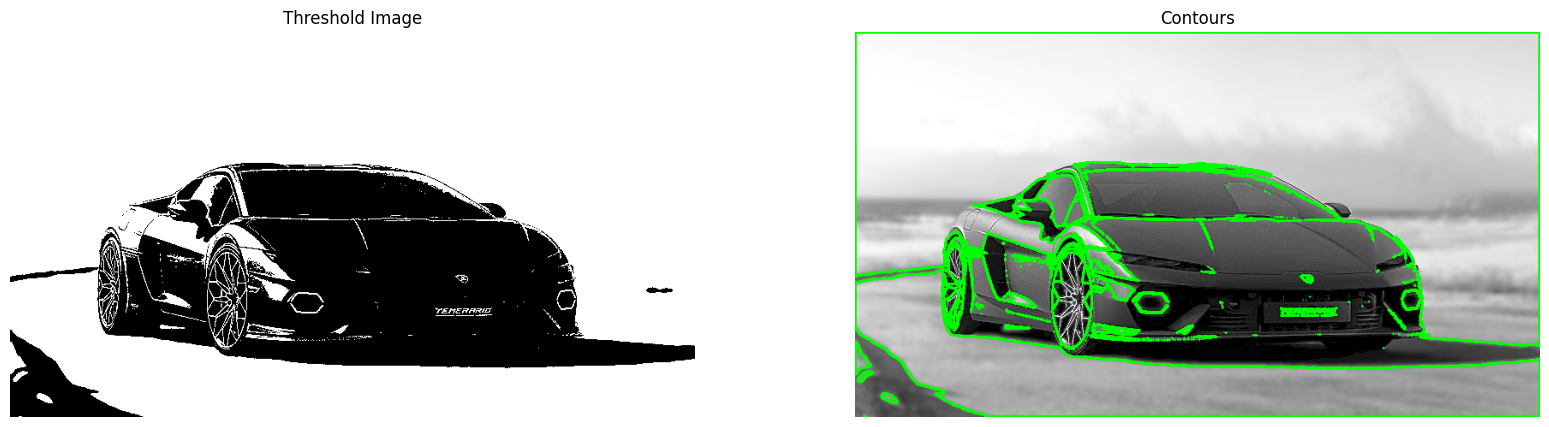

In [2]:
# Load image in grayscale
img = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error: Image not found.")
    exit()

# Apply binary threshold
_, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a color image for drawing contours
img_contours = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

# Draw contours in green
cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)

# Display images
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.title('Threshold Image')
plt.imshow(thresh, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Contours')
plt.imshow(img_contours)
plt.axis('off')

## Exercise 2: Contour Properties
Task: Compute and display the area and perimeter of each contour.

(-0.5, 799.5, 449.5, -0.5)

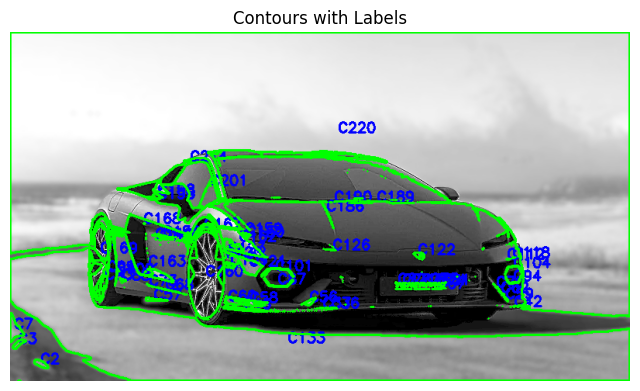

In [3]:
# Load image in grayscale
img = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error: Image not found.")
    exit()

# Apply binary threshold
_, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a color image for drawing
img_contours = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

# Compute and display properties
for i, contour in enumerate(contours):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    # print(f"Contour {i+1}: Area = {area:.2f}, Perimeter = {perimeter:.2f}")
    
    # Draw contour with index label
    M = cv2.moments(contour)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        cv2.putText(img_contours, f"C{i+1}", (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

# Draw contours
cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)

# Display result
plt.figure(figsize=(8, 6))
plt.title('Contours with Labels')
plt.imshow(img_contours)
plt.axis('off')

## Exercise 3: Contour Filtering and Approximation
Task: Filter contours by area and approximate their shapes to simplify them.

(-0.5, 799.5, 449.5, -0.5)

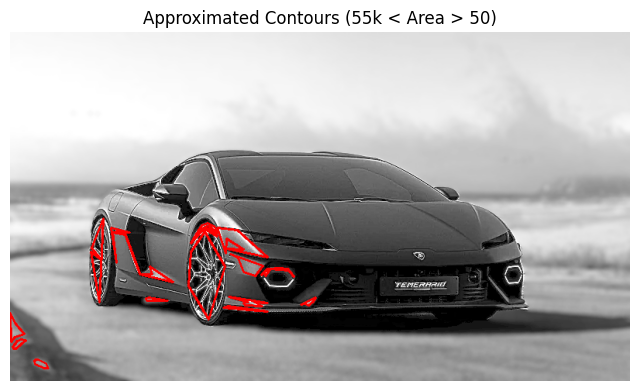

In [4]:
# Load image in grayscale
img = cv2.imread('/kaggle/input/sadams-practice-images-for-computer-vision/car.png', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("Error: Image not found.")
    exit()

# Apply binary threshold
_, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a color image
img_approx = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

# Filter and approximate contours
min_area = 50  # Minimum area threshold
max_area = 55000  # Maximum area threshold

for contour in contours:
    if cv2.contourArea(contour) > min_area and cv2.contourArea(contour) < max_area:
        # Approximate contour
        epsilon = 0.02 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)
        cv2.drawContours(img_approx, [approx], -1, (255, 0, 0), 2)

# Display result
plt.figure(figsize=(8, 6))
plt.title('Approximated Contours (55k < Area > 50)')
plt.imshow(img_approx)
plt.axis('off')

# By **Saddam Umer**

BS AI, SMIU